# Rogers (2004)：调参与稳定性验证

此笔记本在项目目录内运行。原始实验未覆盖。训练目标、数据修订、失败尝试和独立损伤验证都保存在调参报告中；这是优化扩展，不是原论文全部参数的严格复现。

In [1]:
from pathlib import Path
import sys, json, torch
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks/rogers2004/rogers_model.py").exists())
sys.path.insert(0, str(root / "notebooks/rogers2004"))
import rogers_model as m
from tune_model import audit
torch.set_num_threads(1)
output = root / "outputs/rogers2004/tuning"
selection = json.loads((output / "selection.json").read_text())
model, environment = m.load(output / selection["variant"])
with torch.no_grad():
    print(json.dumps(audit(model, environment), indent=2))

D:\复现用文件夹\cls_development_backup_2026-09-19\local_environment\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


{
  "mse": 4.343984619481489e-05,
  "within_005": 0.9991231560707092,
  "bit_accuracy": 1.0,
  "naming": 1.0,
  "max_error": 0.10661321878433228,
  "unsettled": 0,
  "ticks": 388
}


# 继续训练与输入修订实验

原有 `paper_settings` 结果保持不变。三组均从原始400轮权重继续训练；前200轮学习率0.005，后200轮0.002。选择依据是完整网络表现，未使用损伤曲线选参数。

|实验|新增轮数|命名正确率|特征判断正确率|误差<0.05比例|最大误差|未稳定输入|
|---|---:|---:|---:|---:|---:|---:|
|continue|400|100.00%|99.898%|64.67%|0.9751|0|
|tight|400|100.00%|100.000%|87.53%|0.3171|0|
|data|400|100.00%|100.000%|87.36%|0.2689|0|
|stable|200|100.00%|100.000%|88.78%|0.2541|0|
|stable_long|50|0.00%|85.304%|21.60%|0.9847|0|
|adam|1000|100.00%|100.000%|99.91%|0.1066|0|

输入修订只改动8个非标签百科特征：取消重复的概率性动物/人工物标签，并补入图3所示水果共享的4个特征；精确类别标签、名称、视觉输入和随机抽样数保持不变。图3与正文存在其他歧义，因此仍是重建数据，不能称为原始数据。

容差0.01改变了训练目标，并非论文参数的原样复现。小于0.05的统计排除一般名称的歧义线索；命名与稳定性均采用最长2000步的完整网络评估。数据组在旧数据权重基础上继续学习，属于适应实验，不代表从头训练的独立复现。

稳定性扩展组 stable 从 data 组继续：展开56步，对21—56步评分，硬目标0/1与0.01误差死区，学习率0.002。它同时修改了时间展开和目标形式，不能单独归因于其中一项。横轴是各阶段新增轮数；stable 的起点已额外训练400轮。

stable_long 提高学习率到0.005后崩溃，提前停止；不是已完成800轮。adam 从 stable 权重开始，使用全批量Adam (lr=0.001)、56步展开、一般名称的平均特征目标和二元交叉熵。这些都是明确的优化扩展；其横轴是全批量更新次数，不是原来的逐样本SGD轮数。



选用实验：**adam**。选择记录：`selection.json`。

独立损伤随机种子1707，每档50个掩码，共451次评估；92次包含未稳定输入。全部保留，不因不稳定而删除。

|20%损伤指标|实测均值|
|---|---:|
|naming/all/correct|72.14%|
|matching/close|91.42%|
|matching/distant|94.07%|
|matching/unrelated|99.81%|



局限：仅一个初始化和一个环境种子；未拟合患者数据。完整网络表现改善不等于所有损伤状态都稳定，也不等于满足全部原论文数值标准。原始论文与当前曲线没有数字化逐点比较。

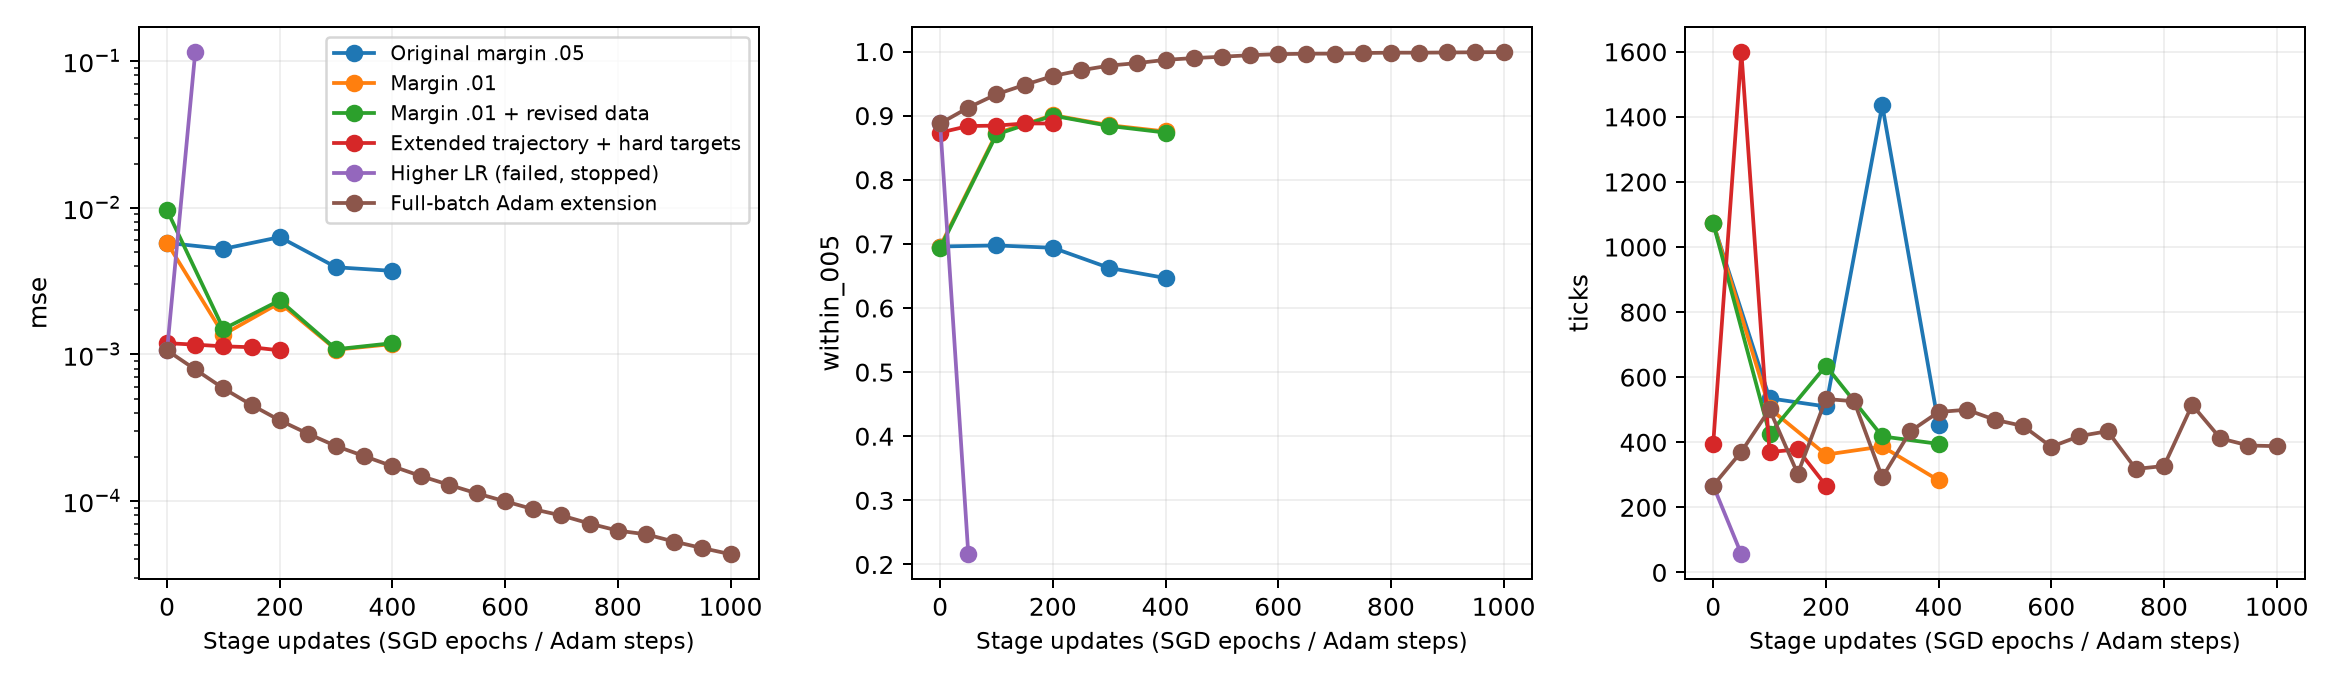

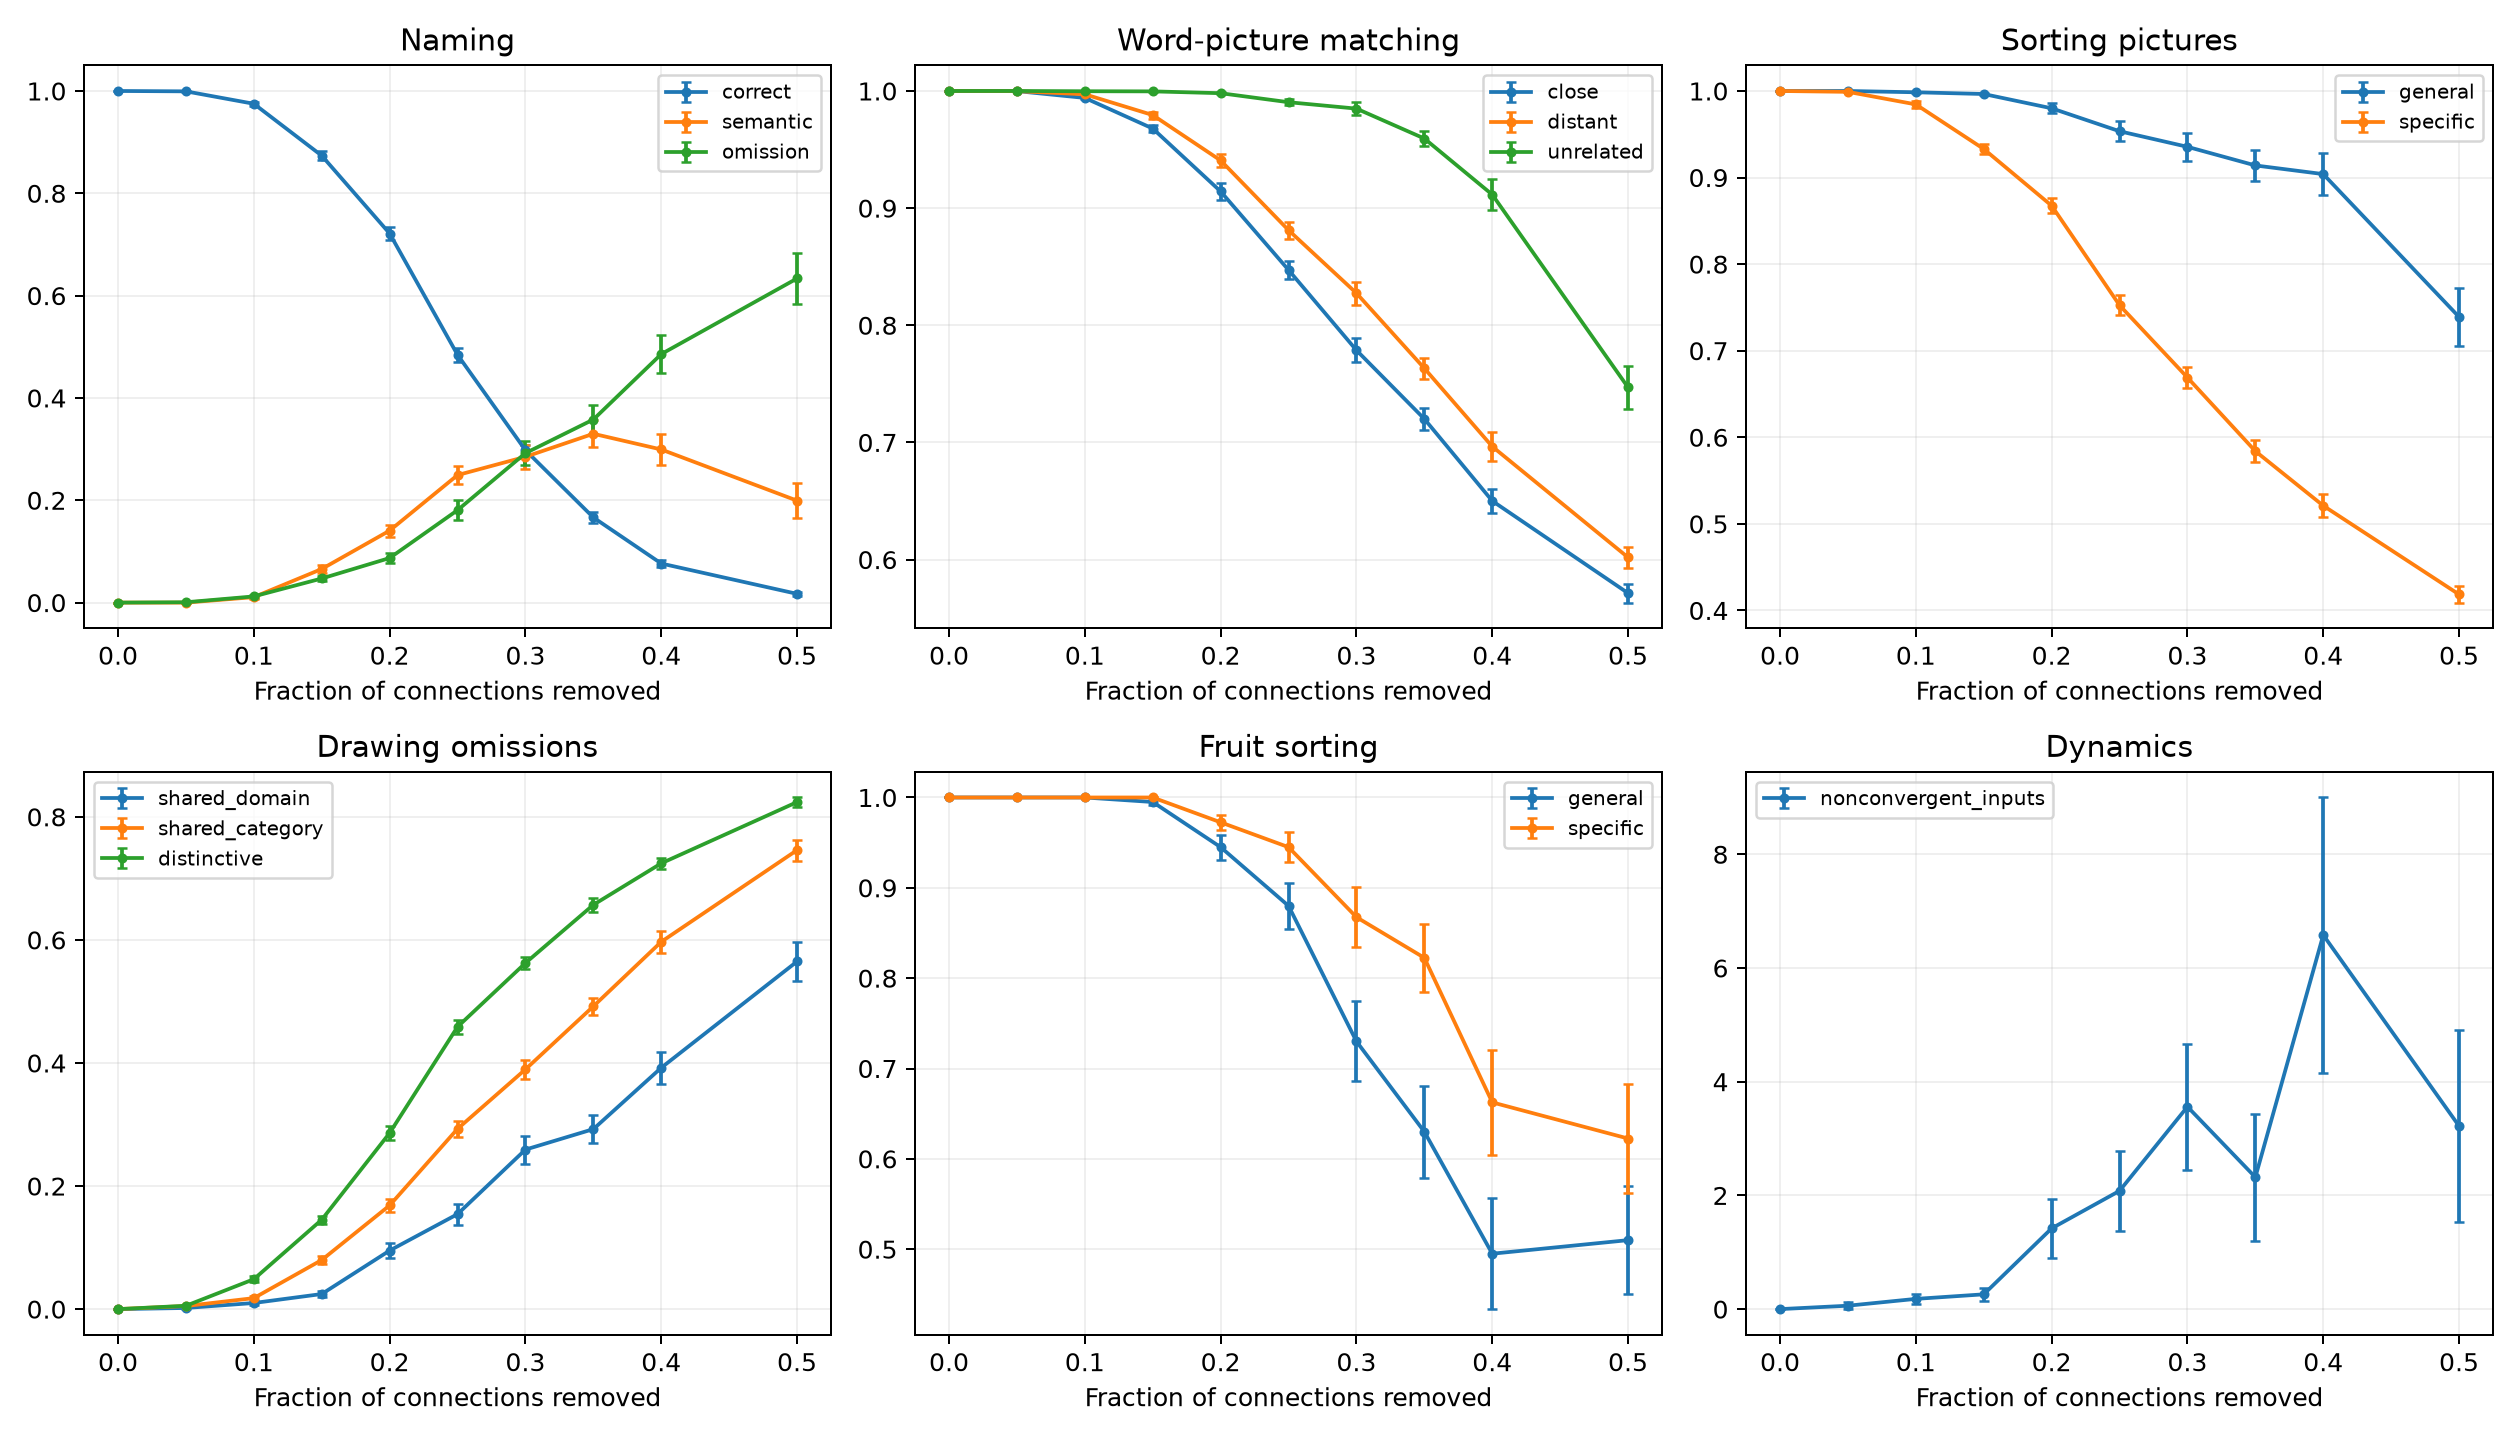

训练入口：`tune_model.py`、`refine_stability.py`、`refine_adam.py`。验证入口：`validate_tuning.py`。具体命令和假设见 `notes/ROGERS2004_NOTES.md`。图中误差条来自一个模型的随机损伤掩码，不代表患者差异或初始化差异。